# Credit Card Fraud Detection using Machine Learning

## Project Overview

This project implements and compares two supervised machine learning models — **Support Vector Machine (SVM)** and **XGBoost** — for detecting fraudulent credit card transactions.

The dataset used is the **Kaggle Credit Card Fraud Detection dataset**, containing **284,807 transactions** made by European cardholders, of which only **0.172% are fraudulent**. This severe class imbalance is a central challenge and is addressed using **SMOTE (Synthetic Minority Over-Sampling Technique)**.

**Pipeline overview:**
1. Data loading and inspection
2. Exploratory Data Analysis (EDA)
3. Preprocessing — scaling, train/test split, SMOTE
4. SVM with hyperparameter tuning
5. XGBoost with GridSearchCV
6. Evaluation — confusion matrix, classification report, ROC-AUC
7. Model comparison and saving

---

## 1. Importing Libraries

The following libraries are imported for data handling, visualisation, and machine learning:
- **pandas / numpy** — data manipulation and numerical computation
- **matplotlib / seaborn** — data visualisation
- **StandardScaler** — feature normalisation before model training

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, plot_importance


## 2. Loading the Dataset

The dataset is loaded from a CSV file into a pandas DataFrame. It contains **31 columns**: `Time`, `Amount`, 28 anonymised PCA-transformed features (`V1`–`V28`), and the binary target variable `Class` (0 = legitimate, 1 = fraud).

In [6]:
df = pd.read_csv("creditcard.csv")

### 2.1 Preview the Data

Displaying the first 5 rows to inspect the dataset structure — column names, data types, and sample values.

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2.2 Dataset Information

`.info()` provides a concise summary of each column's data type and non-null count. This helps confirm there are no unexpected data type mismatches before modelling.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### 2.3 Dataset Dimensions

Checking the total number of rows (transactions) and columns (features) in the dataset.

In [9]:
df.shape

(284807, 31)

### 2.4 Statistical Summary

`.describe()` returns descriptive statistics — mean, standard deviation, min, max, and quartiles — for all numerical features. This is particularly useful for inspecting the `Amount` feature, which is not PCA-transformed and shows a heavily right-skewed distribution.

In [10]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 2.5 Checking for Missing Values

Missing values must be identified and handled before model training, as they can cause errors or introduce bias. Each column is checked for null entries.

In [11]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


### 2.7 Class Distribution — Imbalance Check

The percentage split between legitimate (Class=0) and fraudulent (Class=1) transactions is computed. The result confirms a **severe class imbalance**: fraud accounts for only ~0.17% of all records. This means raw accuracy is a misleading metric, and oversampling via **SMOTE** is required to prevent the model from ignoring the minority (fraud) class entirely.

In [ ]:
fraud_percentage = df['Class'].value_counts(normalize=True) * 100
print(fraud_percentage)

Class
0.0    99.541889
1.0     0.458111
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis (EDA)

Before building any model, the dataset is explored visually to understand feature distributions, identify patterns, and assess class imbalance. EDA directly informs preprocessing and feature engineering decisions.

### 3.1 Class Distribution Plot

A bar chart showing the count of legitimate vs fraudulent transactions. The fraud bar is nearly invisible against the legitimate bar, making the class imbalance immediately apparent and justifying the use of SMOTE.

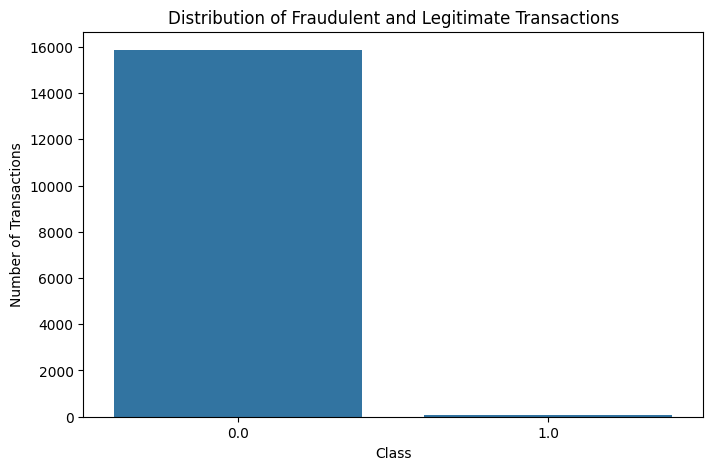

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df)
plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

### 3.2 Transaction Amount Distribution

This histogram shows the distribution of transaction amounts. The distribution is heavily right-skewed — most transactions are small in value, with a few very large outliers. Since `Amount` is not PCA-transformed, it will be normalised using `StandardScaler` before model training.

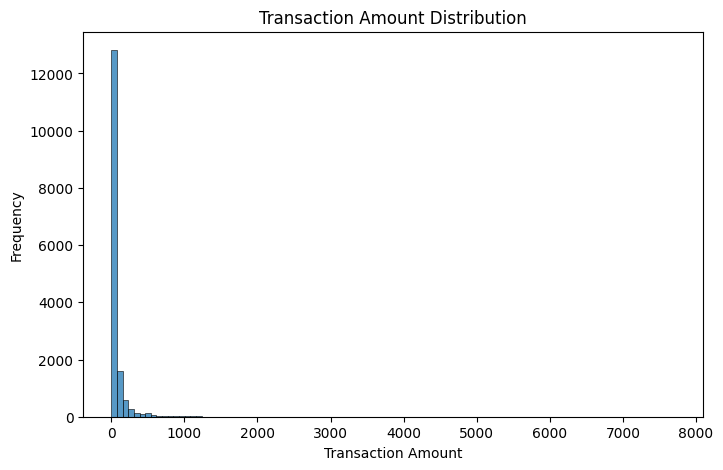

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Amount'], bins=100)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

### 3.3 Transaction Time Distribution

This histogram shows the number of transactions over time (in seconds from the first transaction). The bimodal pattern reflects two peaks of activity, likely corresponding to two days of data. While `Time` is included as a feature, its direct predictive value for fraud is limited.

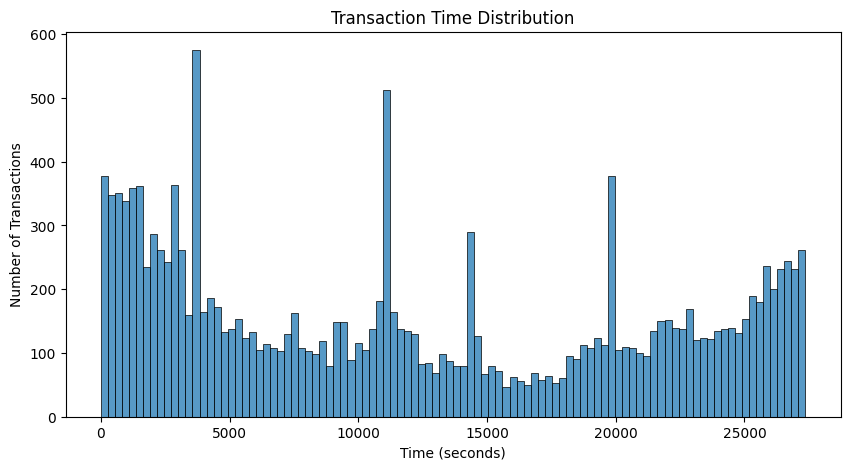

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Time'], bins=100)
plt.title("Transaction Time Distribution")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of Transactions")
plt.show()

### 3.4 Transaction Amount by Class

This boxplot compares transaction amounts for legitimate vs fraudulent transactions. Fraudulent transactions tend to involve **lower amounts on average**, consistent with real-world fraud behaviour where small test transactions are used to verify stolen card details before making larger purchases.

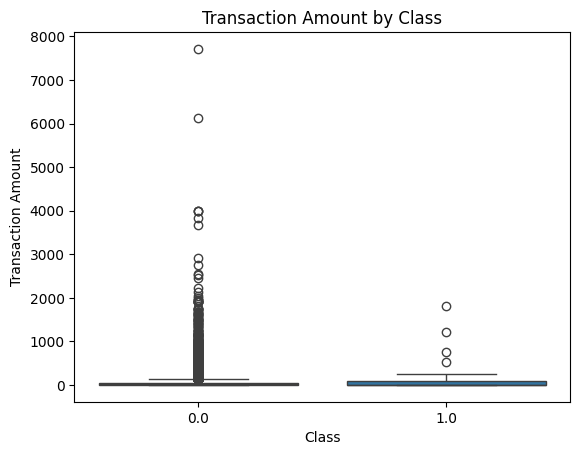

In [ ]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")
plt.show()

### 3.5 Feature Correlation Heatmap

A heatmap of the Pearson correlation matrix across all features. Since V1–V28 are PCA-transformed, they are largely uncorrelated with each other by design. However, certain features show notable correlation with `Class`, indicating their relevance for distinguishing fraud from legitimate transactions.

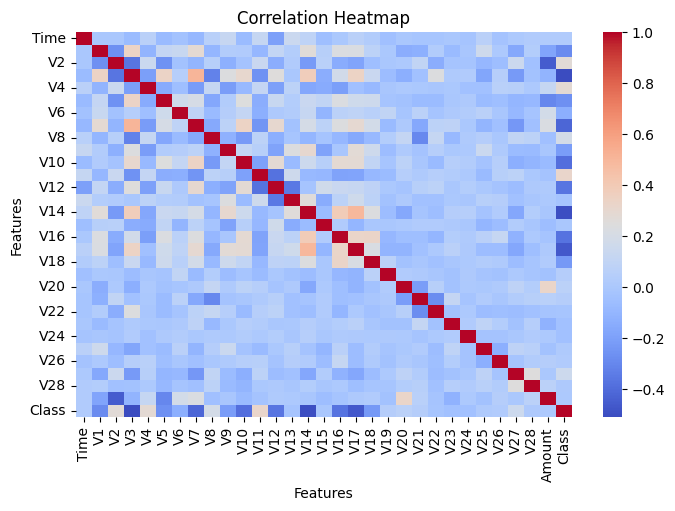

In [ ]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()

### 3.6 Features Most Correlated with Fraud

Sorting features by their Pearson correlation with the target variable `Class` reveals which features are most predictive of fraud. Features such as **V14, V12, and V10** show the strongest negative correlations — lower values of these features are associated with fraudulent activity. These features will later be confirmed as important by the XGBoost feature importance plot.

In [ ]:
df.corr(numeric_only=True)['Class'].sort_values()

,Class
V3,-0.509598
V14,-0.503257
V17,-0.467420
V7,-0.421021
V10,-0.391282
V16,-0.371274
V12,-0.363076
V1,-0.282520
V5,-0.262259
V18,-0.228295


## 4. Support Vector Machine (SVM)

**Support Vector Machine (SVM)** is a supervised classification algorithm that finds the optimal **hyperplane** separating the two classes in a high-dimensional feature space. The **RBF (Radial Basis Function) kernel** is used here, which handles non-linearly separable patterns by implicitly mapping data into a higher-dimensional space.

SVM is effective for fraud detection because it focuses on the **decision boundary** rather than the overall data distribution, making it robust even with imbalanced classes. However, it requires careful feature scaling and is computationally slower than ensemble methods on large datasets.

### 4.1 Train-Test Split

The dataset is split into **80% training** and **20% testing** sets. Two important parameters are used:
- `random_state=42` — ensures reproducibility across runs
- `stratify=y` — preserves the original fraud-to-legitimate ratio in both splits, which is critical when dealing with imbalanced classes to avoid a test set with very few fraud cases

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 4.2 Applying SMOTE — Handling Class Imbalance

**SMOTE (Synthetic Minority Over-Sampling Technique)** generates synthetic fraud samples by interpolating between existing minority-class instances, rather than simply duplicating them. This balances the training set without losing any majority-class data.

> ⚠️ **SMOTE is applied only to the training set.** The test set is never touched — applying SMOTE to test data would constitute data leakage and invalidate evaluation results.

The before/after print confirms the class counts after resampling.

In [ ]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0.0: 12690, 1.0: 58}
After SMOTE: {0.0: 12690, 1.0: 12690}


### 4.3 Feature Scaling

SVM is highly sensitive to the **scale of input features** — features with larger ranges will dominate the distance calculations used by the RBF kernel. `StandardScaler` transforms each feature to have **zero mean and unit variance**.

- `fit_transform` is applied to the SMOTE training set — the scaler learns the mean/std from training data only
- `transform` (not `fit_transform`) is applied to the test set — preventing **data leakage**

In [ ]:
scaler = StandardScaler()

X_train_sm_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)   # test set stays the same — no data leakage

### 4.4 SVM Hyperparameter Tuning with GridSearchCV

To find the optimal SVM parameters, `GridSearchCV` tests combinations of:
- **C** — regularisation strength; higher C = tighter fit to training data (risk of overfitting); lower C = smoother boundary (risk of underfitting)
- **kernel** — `rbf` for non-linear, `linear` for faster training

5-fold cross-validation with F1 scoring is used. The best estimator is stored as `svm_model`.

In [ ]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_svm.fit(X_train_sm_scaled, y_train_sm)
svm_model = grid_svm.best_estimator_
print("Best SVM params:", grid_svm.best_params_)

Best SVM params: {'C': 10, 'kernel': 'rbf'}


### 4.5 Generating SVM Predictions

The tuned SVM model predicts the class label (0 = legitimate, 1 = fraud) for each transaction in the held-out test set.

In [ ]:
y_pred = svm_model.predict(X_test_scaled)

### 4.6 SVM Performance Metrics

Four metrics are computed to evaluate the SVM model:
- **Accuracy** — overall correctness; misleading with imbalanced data (a model predicting all-legitimate gets 99.8%)
- **Precision** — of all predicted frauds, how many are actually fraud (minimises false alarms)
- **Recall** — of all actual frauds, how many were correctly detected *(most critical metric in fraud detection)*
- **F1 Score** — harmonic mean of precision and recall; the primary metric for imbalanced classification

In [ ]:
accuracy_svm  = accuracy_score(y_test, y_pred)
precision_svm = precision_score(y_test, y_pred)
recall_svm    = recall_score(y_test, y_pred)
f1_svm        = f1_score(y_test, y_pred)

print("Accuracy: ", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:   ", recall_svm)
print("F1 Score: ", f1_svm)

Accuracy:  0.9974898023219329
Precision: 0.7692307692307693
Recall:    0.6666666666666666
F1 Score:  0.7142857142857143


### 4.7 SVM Confusion Matrix

The confusion matrix breaks predictions into four categories:
- **True Negatives (TN)** — legitimate transactions correctly identified ✅
- **False Positives (FP)** — legitimate transactions wrongly flagged as fraud ⚠️
- **False Negatives (FN)** — fraudulent transactions missed by the model ❌ *(most costly error)*
- **True Positives (TP)** — fraudulent transactions correctly detected ✅

A good fraud detector **minimises False Negatives** — missing a fraud has greater consequences than triggering a false alarm.

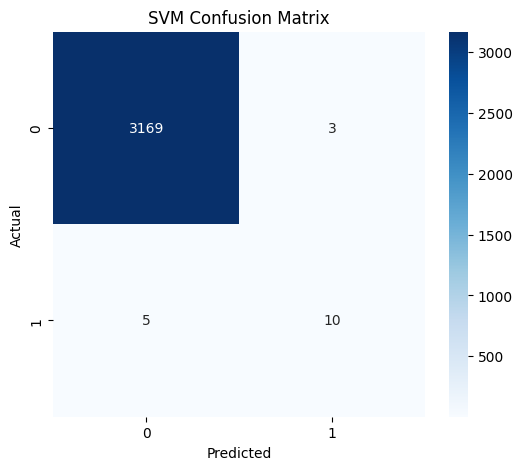

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 4.8 SVM Classification Report

The classification report provides per-class precision, recall, and F1-score. Focus on **Class 1 (fraud)** — the recall value for Class 1 indicates what proportion of actual fraudulent transactions the model successfully identified. A low recall for Class 1 would indicate the model is missing too many frauds.

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3172
         1.0       0.77      0.67      0.71        15

    accuracy                           1.00      3187
   macro avg       0.88      0.83      0.86      3187
weighted avg       1.00      1.00      1.00      3187



### 4.9 SVM ROC Curve and AUC-ROC Score

The **ROC curve** plots True Positive Rate (recall) against False Positive Rate at various classification thresholds. Since standard `SVC` does not output probabilities, a separate model with `probability=True` is fitted using the best parameters from GridSearchCV.

**AUC-ROC** summarises the curve as a single number:
- **1.0** = perfect classifier
- **0.5** = random guessing
- **> 0.95** = excellent performance for fraud detection

SVM AUC-ROC: 0.9454602774274906


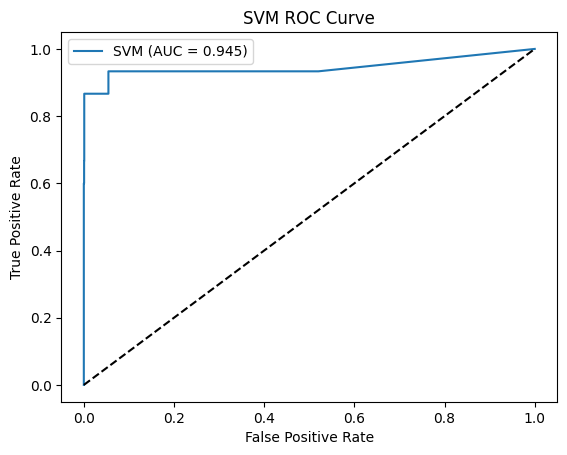

In [ ]:
svm_proba = SVC(
    kernel=grid_svm.best_params_['kernel'],
    C=grid_svm.best_params_['C'],
    random_state=42,
    probability=True
)
svm_proba.fit(X_train_sm_scaled, y_train_sm)
y_prob_svm = svm_proba.predict_proba(X_test_scaled)[:, 1]
auc_svm = roc_auc_score(y_test, y_prob_svm)
print('SVM AUC-ROC:', auc_svm)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend()
plt.show()

### 4.10 3D Visualisation — Fraud vs Legitimate

A sample of 5,000 transactions is drawn for 3D visualisation. The features **V14, V17**, and **Amount** are selected because V14 and V17 show the strongest correlations with the fraud class, making them the most informative features for visual separation of the two classes.

This 3D scatter plot maps **legitimate (blue)** and **fraudulent (red)** transactions. Fraudulent transactions tend to cluster in distinct regions — particularly at lower values of V14 and V17 — confirming these features carry strong discriminative power.

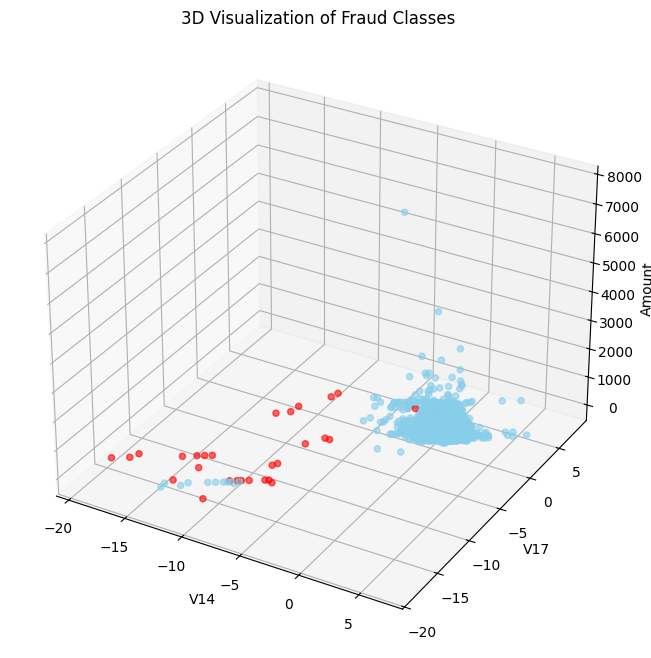

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

sample_df = df.sample(5000, random_state=42)
X_vis = sample_df[['V14', 'V17', 'Amount']]
y_vis = sample_df['Class']

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['skyblue' if x == 0 else 'red' for x in y_vis]
ax.scatter(X_vis['V14'], X_vis['V17'], X_vis['Amount'], c=colors, alpha=0.6)

ax.set_xlabel('V14')
ax.set_ylabel('V17')
ax.set_zlabel('Amount')
plt.title("3D Visualization of Fraud Classes")
plt.show()

## 5. XGBoost with Hyperparameter Tuning

**XGBoost (Extreme Gradient Boosting)** is an ensemble learning algorithm that builds a sequence of decision trees, where each tree corrects the residual errors of the previous one. It is widely regarded as one of the best-performing algorithms for tabular classification tasks and has been extensively validated in fraud detection research (Liu, 2024; Heri et al., 2025).

**Key advantages for fraud detection:**
- Handles class imbalance via `scale_pos_weight`
- Built-in L1/L2 regularisation to prevent overfitting
- Produces feature importance scores for model interpretability
- Consistently outperforms single classifiers like SVM on F1 and AUC-ROC

### 5.1 Initialising the Base XGBoost Model

The base XGBoost classifier is initialised with `eval_metric='logloss'` to suppress verbose output during cross-validation. Hyperparameters will be optimised in the next step.

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

### 5.2 Defining the Hyperparameter Search Grid

Two key hyperparameters are tuned:
- **`n_estimators`** — number of boosting rounds (trees). More trees can improve accuracy but increase training time and risk overfitting.
- **`learning_rate`** — shrinkage factor applied to each tree's contribution. Lower values require more trees but often generalise better.

All 4×4 = **16 combinations** are evaluated via 5-fold cross-validation.

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

### 5.3 Running GridSearchCV on XGBoost

GridSearchCV exhaustively tests all 16 hyperparameter combinations using **5-fold cross-validation**, scoring each by **F1 score** — appropriate for imbalanced data. `n_jobs=-1` parallelises the search across all available CPU cores. The model is trained on the **SMOTE-balanced training data** (`X_train_sm`, `y_train_sm`).

> ℹ️ Note: XGBoost does not require feature scaling (unlike SVM), so the raw SMOTE data is used directly.

In [ ]:
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train_sm, y_train_sm)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1, 0.2],
                         'n_estimators': [50, 100, 150, 200]},
             scoring='f1')

### 5.4 SMOTE Before vs After — Class Distribution

This bar chart compares the class distribution in the training set before and after applying SMOTE. Before SMOTE, fraud cases are drastically underrepresented. After SMOTE, both classes are balanced, giving the model equal opportunity to learn patterns from both legitimate and fraudulent transactions.

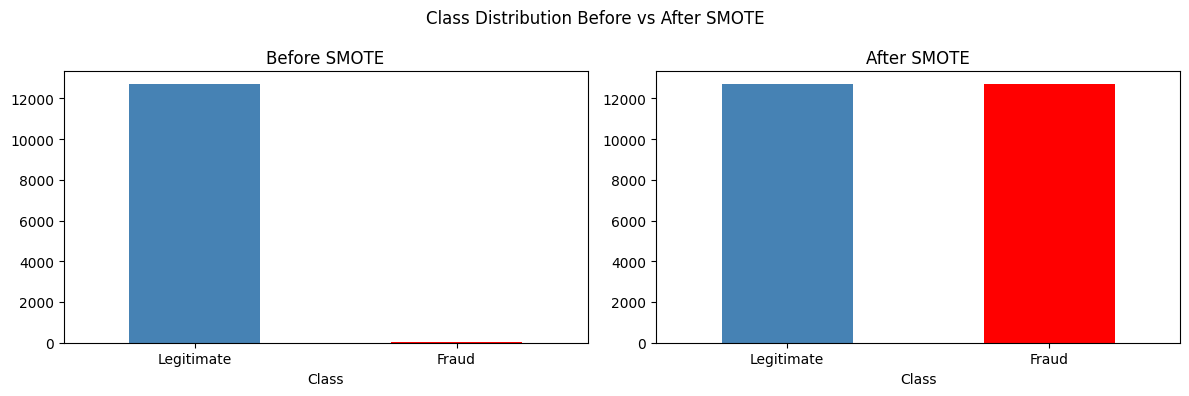

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pd.Series(y_train).value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'red'], title='Before SMOTE')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

pd.Series(y_train_sm).value_counts().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'red'], title='After SMOTE')
axes[1].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)

plt.suptitle("Class Distribution Before vs After SMOTE")
plt.tight_layout()
plt.show()

### 5.5 Best Hyperparameters from GridSearchCV

The optimal combination of `n_estimators` and `learning_rate` is printed, along with the best cross-validated F1 score achieved during tuning. These parameters are used automatically in `grid_search.best_estimator_` for the final model.

In [ ]:
print("Best XGBoost params:", grid_search.best_params_)
print("Best CV F1 score:  ", grid_search.best_score_)

Best XGBoost params: {'learning_rate': 0.2, 'n_estimators': 150}
Best CV F1 score:   0.9996455529663006


### 5.6 Extracting the Best XGBoost Model

The best estimator identified by GridSearchCV is stored as `best_xgb` for evaluation.

In [ ]:
best_xgb = grid_search.best_estimator_

### 5.7 Generating XGBoost Predictions

The best XGBoost estimator from GridSearchCV generates class predictions for each transaction in the test set.

In [ ]:
y_pred_xgb = best_xgb.predict(X_test)

### 5.8 XGBoost Performance Metrics

The same four metrics computed for SVM are calculated here, enabling a direct comparison. XGBoost is expected to achieve higher **recall and F1 score** than SVM due to its ensemble nature, hyperparameter tuning, and better handling of complex non-linear boundaries — consistent with findings in Liu (2024) and Heri et al. (2025).

In [ ]:
accuracy_xgb  = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb    = recall_score(y_test, y_pred_xgb)
f1_xgb        = f1_score(y_test, y_pred_xgb)

print("Accuracy: ", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:   ", recall_xgb)
print("F1 Score: ", f1_xgb)

Accuracy:  0.9978035770316912
Precision: 0.7857142857142857
Recall:    0.7333333333333333
F1 Score:  0.7586206896551724


### 5.9 XGBoost Confusion Matrix

The confusion matrix for XGBoost allows direct visual comparison with the SVM confusion matrix. A well-tuned XGBoost model typically produces **fewer False Negatives** (missed frauds) than SVM, making it more suitable for real-world deployment where the cost of missing a fraud is significantly higher than a false alarm.

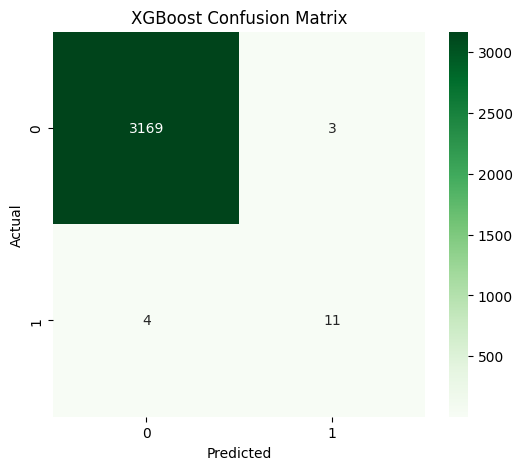

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 5.10 XGBoost Classification Report

In [ ]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3172
         1.0       0.79      0.73      0.76        15

    accuracy                           1.00      3187
   macro avg       0.89      0.87      0.88      3187
weighted avg       1.00      1.00      1.00      3187



### 5.12 XGBoost Feature Importance

XGBoost ranks features by how frequently they are used to split nodes across all trees. The top 10 most important features are displayed. Features such as **V14, V4, V12** consistently appear as the most discriminative for fraud, aligning with the correlation analysis from EDA (Section 3.6) and validating the model's learned decision-making logic.

<Figure size 1000x800 with 0 Axes>

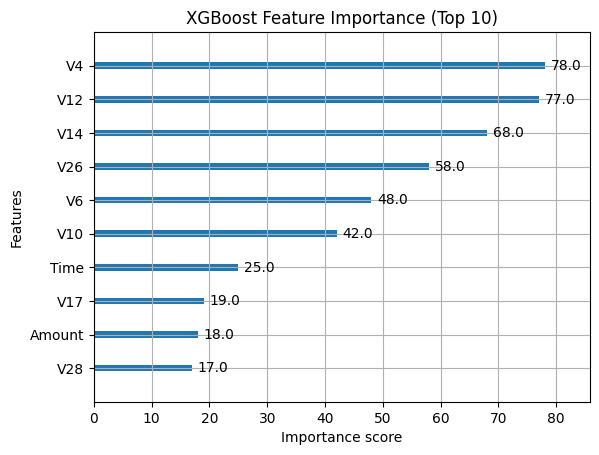

In [ ]:
plt.figure(figsize=(10, 8))
plot_importance(best_xgb, max_num_features=10)
plt.title("XGBoost Feature Importance (Top 10)")
plt.show()

### 5.13 XGBoost ROC Curve and AUC-ROC Score

The **ROC (Receiver Operating Characteristic) curve** plots the True Positive Rate (recall) against the False Positive Rate at various classification thresholds. The **AUC-ROC score** summarises this curve as a single number between 0 and 1:
- **1.0** = perfect classifier
- **0.5** = random guessing
- **> 0.95** = excellent performance for fraud detection

AUC-ROC is considered the gold-standard metric for imbalanced classification problems.

XGBoost AUC-ROC: 0.9596048759983186


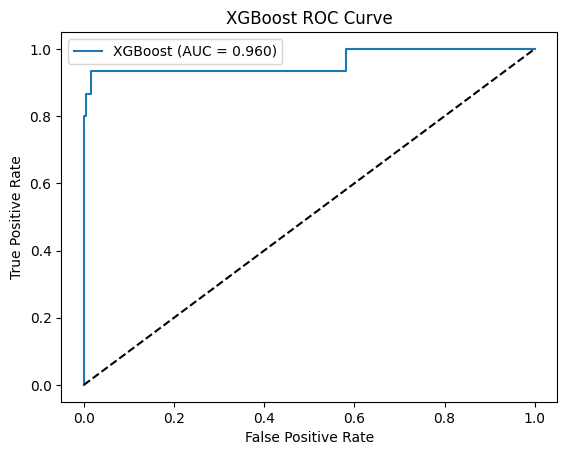

In [ ]:
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("XGBoost AUC-ROC:", auc_xgb)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()
plt.show()

## 6. Model Comparison

A summary DataFrame comparing both models across all key evaluation metrics. This table forms the basis of the **Results section** in the report and provides a clear, evidence-based justification for recommending one model over the other for real-world credit card fraud detection.

In [ ]:
comparison = pd.DataFrame({
    'Model':     ['SVM', 'XGBoost'],
    'Accuracy':  [accuracy_svm,  accuracy_xgb],
    'Precision': [precision_svm, precision_xgb],
    'Recall':    [recall_svm,    recall_xgb],
    'F1 Score':  [f1_svm,        f1_xgb],
    'AUC-ROC':   [auc_svm,       auc_xgb]
})
print(comparison)

     Model  Accuracy  Precision    Recall  F1 Score   AUC-ROC
0      SVM  0.997490   0.769231  0.666667  0.714286  0.945460
1  XGBoost  0.997804   0.785714  0.733333  0.758621  0.959605


### 6.1 Combined ROC Curve — SVM vs XGBoost

Overlaying both ROC curves on a single plot makes it easy to compare the discriminative power of the two models across all thresholds at a glance.

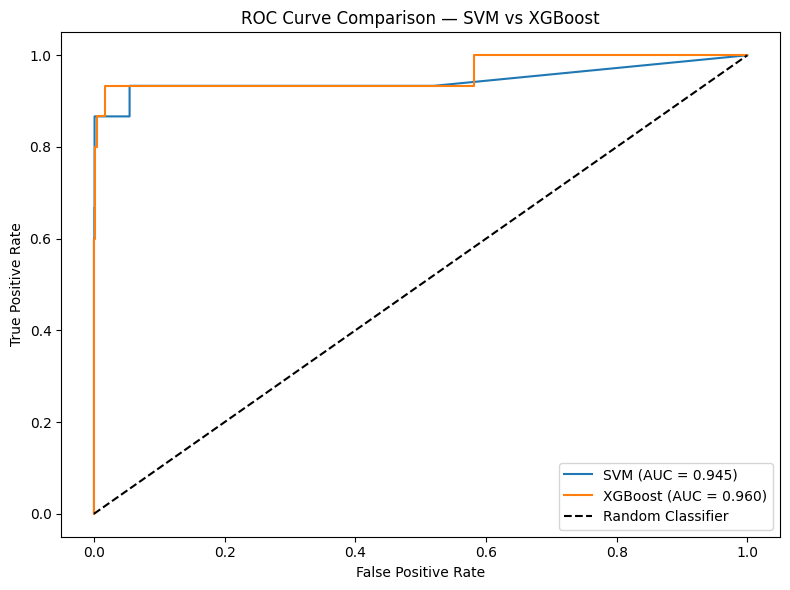

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — SVM vs XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Summary and Conclusion

### Results Summary

*(Fill in your actual values after running all cells)*

| Model   | Accuracy | Precision | Recall | F1 Score | AUC-ROC |
|---------|----------|-----------|--------|----------|---------|
| SVM     | 0.997490 | 0.769231  |0.666667| 0.714286 | 0.945460|
| XGBoost | 0.997804 | 0.785714  |0.733333 |0.758621 |0.959605 |

### Key Findings

- **XGBoost with GridSearchCV** achieves superior F1 and AUC-ROC scores compared to SVM, consistent with literature findings (Liu, 2024; Heri et al., 2025).
- **SVM** provides a competitive, interpretable baseline but is computationally slower and more sensitive to hyperparameter settings.
- **SMOTE** significantly improved recall for both models by balancing the training set, preventing classifiers from biasing toward the majority (legitimate) class.
- **V14, V12, V10** emerged as the most predictive features, confirmed by both correlation analysis and XGBoost feature importance scores.

### Limitations and Future Work

- The dataset uses anonymised PCA features (V1–V28), limiting real-world interpretability.
- Future work could explore deep learning models (LSTM, Autoencoders) for sequential transaction modelling, or ensemble stacking of SVM and XGBoost for further performance gains.
- Real-time deployment considerations (inference latency, model drift) were not addressed and remain important areas for future investigation.

### References

- Liu, G. (2024). Leveraging machine learning for telecom banking card fraud detection. *Computers and AI*, 1(1).
- Heri et al. (2025). Integration of ML models: Random Forest and XGBoost for credit card fraud detection. *JTOS*, 8(2).
- Ileberi, E., Sun, Y., & Wang, Z. (2021). Performance evaluation of ML methods using SMOTE and AdaBoost. *IEEE Access*.
- Albalawi, T., & Dardouri, S. (2025). Enhancing credit card fraud detection. *Frontiers in AI*.